### This script is used to plot the relative feature importance barplots for the paper:

* 6 plots are generated: absolute concentrations rOC, DIN and SRP and Redfield normalized concentrations rOC_RFR, DIN_RFR and SRP_RFR
* each plot shows all features which showed an outstanding importance for the corresponding target variable (above a certain clear cut-off)

### input files: 
* six csv files: f"/output_data/ML_analysis/feature_importances/{target_var}_{model_type}/{target_var}_ranking_relative_perm_imp_5splits.csv"

### output files:
* 6 svg/png/pdf files in cnp_synthesis/figures/CNP_paper_plots

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [6]:
targets = ['median_DOC_TOC_bioav', 'median_DIN', 'median_SRP', 'c_imbal','n_imbal', 'p_imbal']

target_names = {'median_DOC_TOC_bioav':r'rOC', 
                'median_DIN':r'rN', 
                'median_SRP':r'rP', 
                'c_imbal':r'rOC$_{\mathrm{RFR}}$',
                'n_imbal': r'rN$_{\mathrm{RFR}}$', 
                'p_imbal': r'rP$_{\mathrm{RFR}}$'}

# set the number of outstanding features for each target:
nr_outstanding_feat = {
    "median_DOC_TOC_bioav": 5,
    "median_DIN": 6,
    "median_SRP": 7,
    "c_imbal": 5,
    "n_imbal": 6,
    "p_imbal": 4
}


# Dictionary indicating the impact of each feature
rOC_imp = {
    'slp_dg_uav': 'negative',
    'sgr_dk_sav': 'negative',
    'ele_mt_uav': 'negative',
    'twi90': 'positive',
    'kar_pc_use': 'negative'
}

DIN_imp = {
    'ppd_pk_uav': 'positive',
    'pet_mm_uyr': 'negative',
    'crp_pc_use': 'positive',
    'for_pc_use': 'negative',
    'pre_mm_uyr': 'negative',
    'aet_mm_uyr': 'negative'
}

SRP_imp = {
    'ppd_pk_uav': 'positive',
    'pre_mm_uyr': 'negative',
    'for_pc_use': 'negative',
    'crp_pc_use': 'positive',
    'slp_dg_uav': 'negative',
    'gdp_ud_usu': 'positive',
    'aet_mm_uyr': 'negative'
}

c_imbal_imp = {
    'ppd_pk_uav': 'negative',
    'wet_pc_ug2': 'positive',
    'pet_mm_uyr': 'positive',
    'slp_dg_uav': 'negative',
    'slt_pc_uav': 'negative'
}

n_imbal_imp = {
    'pet_mm_uyr': 'negative',
    'swc_pc_uyr': 'positive',
    'wet_pc_ug2': 'negative',
    'tmp_dc_uyr': 'negative',
    'ppd_pk_uav': 'positive',
    'hdi_ix_sav': 'positive'
}

p_imbal_imp = {
    'swc_pc_uyr': 'negative',
    'pet_mm_uyr': 'positive',
    'hdi_ix_sav': 'negative',
    'kar_pc_use': 'negative'
}

# Dictionary to store the impact direction data for each target
impact_data = {
    'median_DOC_TOC_bioav': rOC_imp,
    'median_DIN': DIN_imp,
    'median_SRP': SRP_imp,
    'c_imbal': c_imbal_imp,
    'n_imbal': n_imbal_imp,
    'p_imbal': p_imbal_imp
}


In [7]:
### Create a dictionary containing target variables units: slp, dor, temperature and hdi were converted, check units, if they are plausible:
feature_var_units = {
    'UP_AREA':'[km$^{2}$]' ,
    'twi90':'[-]', 
    'slp_dg_uav':'[°]',
    'for_pc_use':'[%]',
    'crp_pc_use':'[%]',
    'pst_pc_use':'[%]',
    'ppd_pk_uav':'[people km$^{-2}$]',
    'run_mm_syr':'[mm year$^{-1}$]',
    'inu_pc_umn':'[%]',
    'dor_pc_pva':'[%]',
    'ria_ha_usu_perkm2':'[hectares km$^{-2}$]', 
    'riv_tc_usu_perkm2':'[hectares km$^{-2}$]',
    'ele_mt_uav':'[m a.s.l]',
    'sgr_dk_sav':'[dm km$^{-1}$]',
    'tmp_dc_uyr':'[°C]', 
    'pre_mm_uyr':'[mm year$^{-1}$]',
    'pet_mm_uyr':'[mm year$^{-1}$]',
    'aet_mm_uyr':'[mm year$^{-1}$]',
    'snw_pc_uyr':'[%]',
    'wet_pc_ug2':'[%]',
    'ire_pc_use':'[%]',
    'gla_pc_use':'[%]',
    'prm_pc_use':'[%]',
    'pac_pc_use':'[%]',
    'cly_pc_uav':'[%]',
    'slt_pc_uav':'[%]',
    'snd_pc_uav':'[%]',
    'soc_th_uav':'[tonnes hectare$^{-1}$]',
    'swc_pc_uyr':'[%]',
    'kar_pc_use':'[%]',
    'ero_kh_uav':'[kg hectare$^{-1}$ year$^{-1}$]',
    'gdp_ud_usu':'[US dollers]',
    'hdi_ix_sav':'[-]'
}

### Create a dictionary containing target variables units: slp, dor, temperature and hdi were converted, check units, if they are plausible:
feature_var_names = {
    'UP_AREA':'Upstream area' ,
    'twi90':'90th percentile\ntopographic wetness index', 
    'slp_dg_uav':'Terrain slope',
    'for_pc_use':'Forest extent',
    'crp_pc_use':'Cropland extent',
    'pst_pc_use':'Pasture extent',
    'ppd_pk_uav':'Population density',
    'run_mm_syr':'Runoff',
    'inu_pc_umn':'Inundation extent',
    'dor_pc_pva':'Degree of regulation',
    'ria_ha_usu_perkm2':'River area', 
    'riv_tc_usu_perkm2':'River volume',
    'ele_mt_uav':'Mean elevation', # [m a.s.l]',
    'sgr_dk_sav':'Stream gradient',
    'tmp_dc_uyr':'Mean air temperature', 
    'pre_mm_uyr':'Mean precipitation',
    'pet_mm_uyr':'Potential\n evapotranspiration',
    'aet_mm_uyr':'Actual evapotranspiration',
    'snw_pc_uyr':'Snow cover',
    'wet_pc_ug2':'Wetland extent',
    'ire_pc_use':'Irrigated land extent',
    'gla_pc_use':'Glacier extent',
    'prm_pc_use':'Permafrost extent',
    'pac_pc_use':'Protected area extent',
    'cly_pc_uav':'Clay content',
    'slt_pc_uav':'Silt content',
    'snd_pc_uav':'Sand content',
    'soc_th_uav':'Soil organic carbon',
    'swc_pc_uyr':'Soil water content',
    'kar_pc_use':'Karst extent',
    'ero_kh_uav':'Erosion',
    'gdp_ud_usu':'Gross domestic product',
    'hdi_ix_sav':'Human development index'
}

In [8]:
target_var = 'median_DOC_TOC_bioav'
data = pd.read_csv(f"../../../output_data/ML_analysis/feature_importances/{target_var}_GBR/{target_var}_ranking_relative_perm_imp_5splits.csv")

In [9]:
data

,Unnamed: 0,rank,feat_run_1,mean_run_1,std_run_1,feat_run_2,mean_run_2,std_run_2,feat_run_3,mean_run_3,std_run_3,feat_run_4,mean_run_4,std_run_4,feat_run_5,mean_run_5,std_run_5,feat_all_5runs,mean_all_5runs,sd_all_5runs
0,0,1,slp_dg_uav,27.917889,0.974581,slp_dg_uav,25.544286,1.143239,slp_dg_uav,25.398977,1.356723,slp_dg_uav,29.117848,1.518639,slp_dg_uav,29.318546,1.176748,slp_dg_uav,27.459509,2.103264
1,1,2,sgr_dk_sav,10.970183,0.841799,ele_mt_uav,9.647481,0.849796,sgr_dk_sav,8.160991,0.994159,sgr_dk_sav,11.280777,1.050041,sgr_dk_sav,11.778504,0.940700,sgr_dk_sav,9.881886,2.070788
2,2,3,ele_mt_uav,9.857257,0.728990,sgr_dk_sav,7.218974,0.982500,ele_mt_uav,8.075166,0.798626,ele_mt_uav,9.897989,0.950646,ele_mt_uav,9.360741,0.961951,ele_mt_uav,9.367727,1.094560
3,3,4,twi90,4.152567,0.426511,twi90,5.950840,1.115549,twi90,5.417942,0.676936,twi90,5.140965,0.887256,twi90,4.710749,0.639641,twi90,5.074613,0.995347
4,4,5,kar_pc_use,3.752394,0.411987,tmp_dc_uyr,5.098091,0.338935,UP_AREA,5.122493,0.591190,kar_pc_use,4.182798,0.733214,kar_pc_use,4.673794,0.650560,kar_pc_use,4.132127,0.651906
5,5,6,wet_pc_ug2,3.412624,0.455262,kar_pc_use,4.077519,0.549708,kar_pc_use,3.974131,0.473343,ero_kh_uav,3.116899,0.379888,wet_pc_ug2,3.532654,0.474813,pre_mm_uyr,3.153620,0.557617
6,6,7,tmp_dc_uyr,2.949164,0.307584,prm_pc_use,3.728736,0.380487,pre_mm_uyr,3.658302,0.465555,run_mm_syr,3.035846,0.670525,ero_kh_uav,3.408487,0.449733,crp_pc_use,3.122727,0.709153
7,7,8,pre_mm_uyr,2.863846,0.322850,crp_pc_use,3.508173,0.760990,tmp_dc_uyr,3.284245,0.311297,wet_pc_ug2,2.971851,0.680506,crp_pc_use,3.370734,0.584740,tmp_dc_uyr,3.065235,1.224830
8,8,9,crp_pc_use,2.782937,0.411189,pre_mm_uyr,3.435440,0.452995,crp_pc_use,3.145269,0.698482,for_pc_use,2.930638,0.543378,pre_mm_uyr,2.937808,0.468782,wet_pc_ug2,2.913097,0.755697
9,9,10,pet_mm_uyr,2.759662,0.316907,snw_pc_uyr,3.301079,0.376242,ero_kh_uav,2.673286,0.392464,pre_mm_uyr,2.872703,0.514944,run_mm_syr,2.736552,0.515005,ero_kh_uav,2.863742,0.512971


In [10]:
# a function to add panel letters to the sublots:
titles = ['a.', 'c.', 'e.', 'b.', 'd.', 'f.']

def add_panel_letter(ax, letter, x=-0.6, y=1.1, fontsize=24):
    ax.text(x, y, letter, transform=ax.transAxes, fontsize=fontsize, fontweight='bold', va='top', ha='right')


C:\Users\alexd\AppData\Local\Temp\ipykernel_42848\989656284.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feats_names, fontsize=20, ha = 'right')
C:\Users\alexd\AppData\Local\Temp\ipykernel_42848\989656284.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feats_names, fontsize=20, ha = 'right')
C:\Users\alexd\AppData\Local\Temp\ipykernel_42848\989656284.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feats_names, fontsize=20, ha = 'right')
C:\Users\alexd\AppData\Local\Temp\ipykernel_42848\989656284.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feats_names, fon

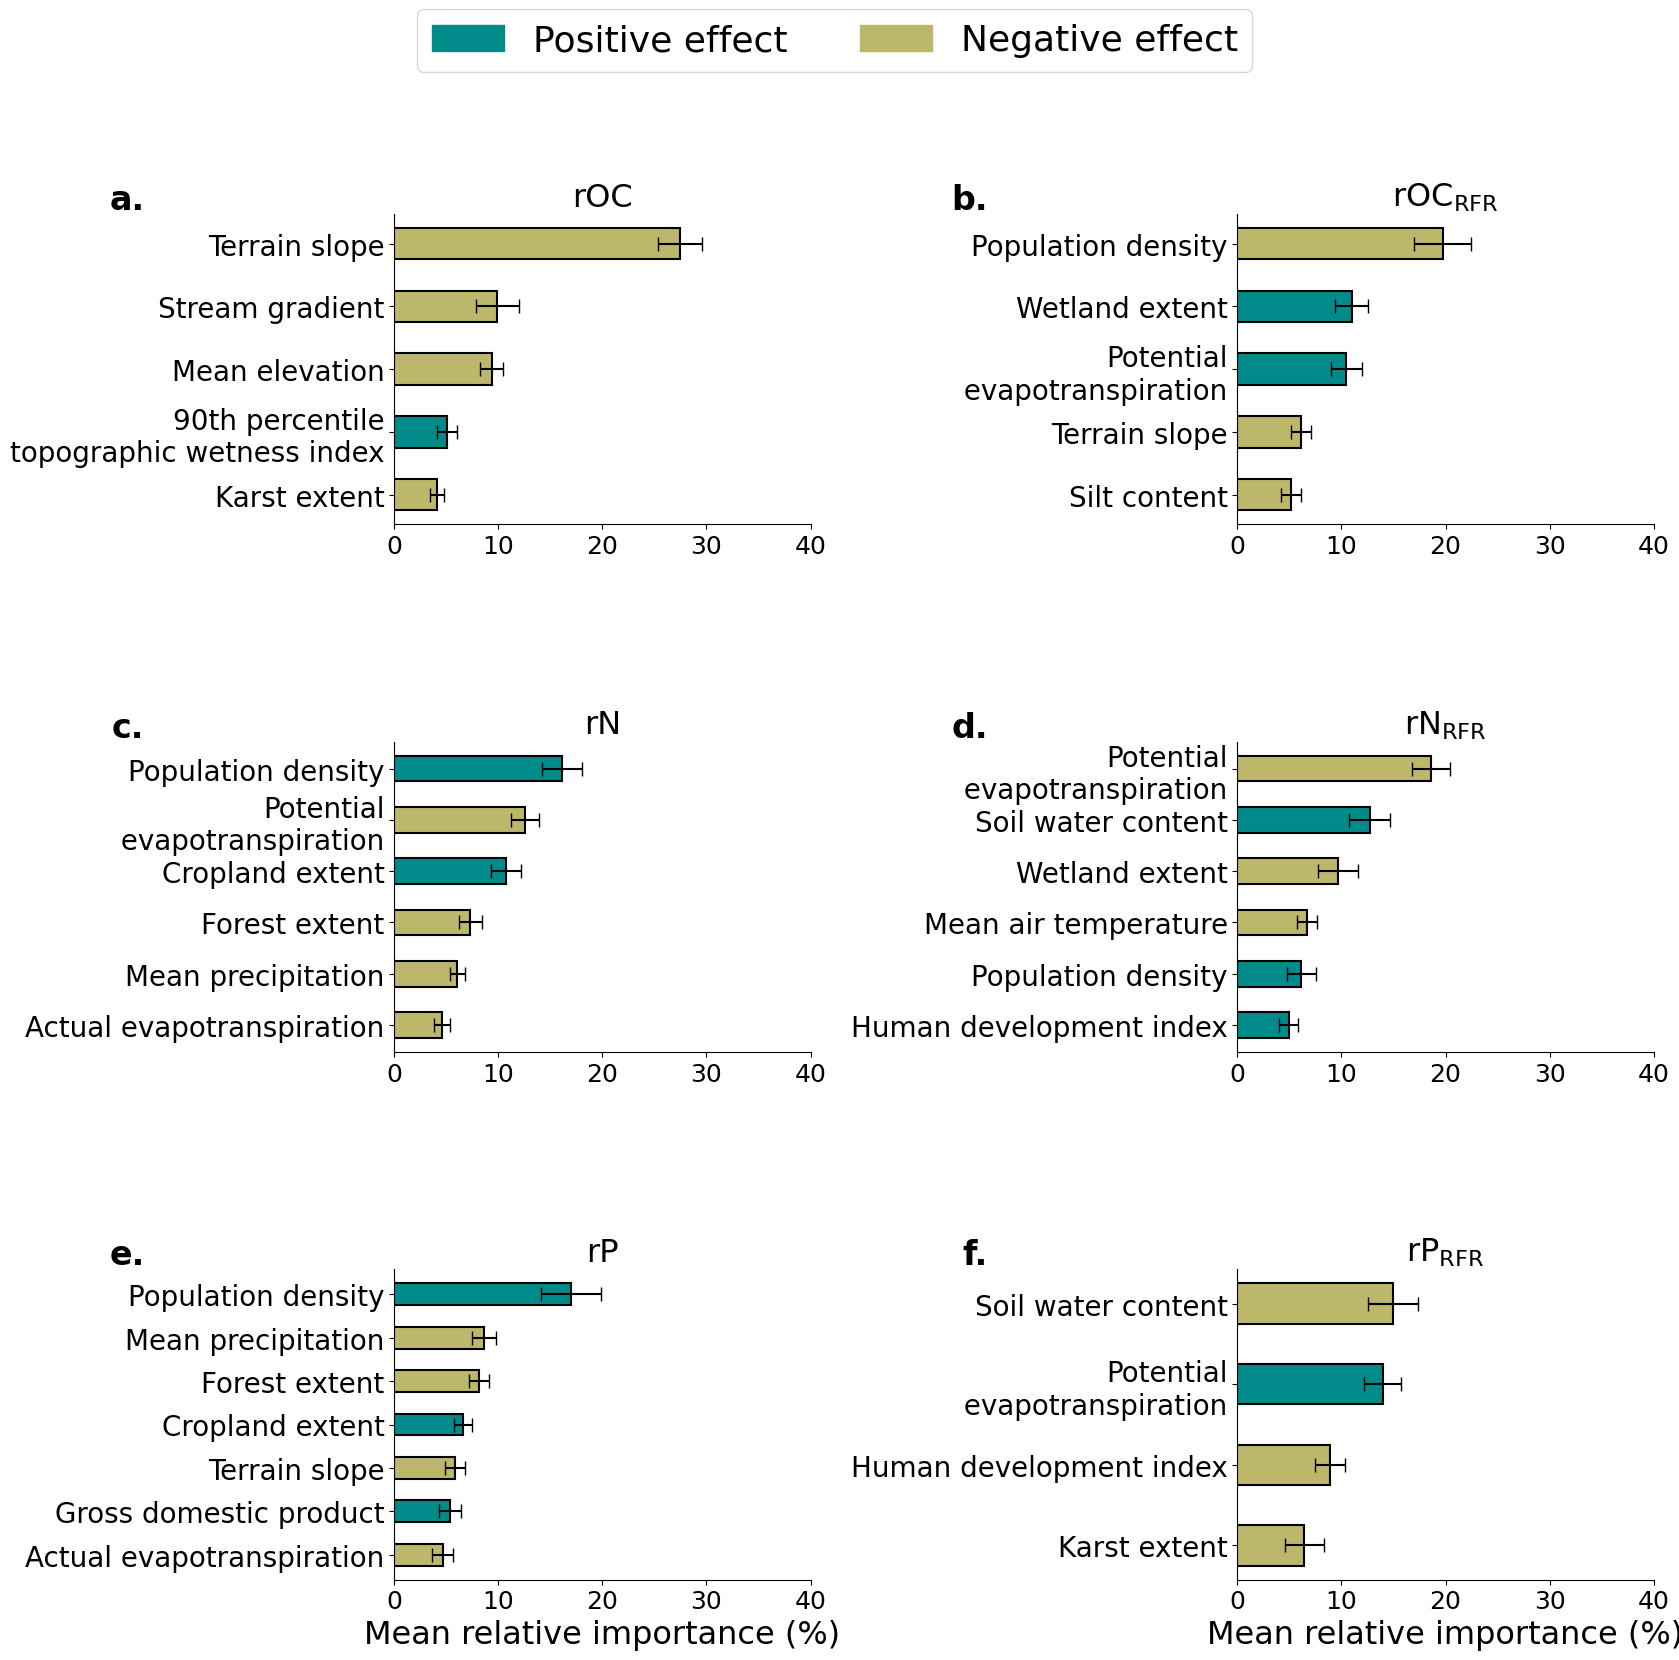

In [11]:



fig1, axes = plt.subplots(3, 2, figsize=(17, 15), sharex=False)

axes = axes.T # transpose axes to iterate column first
axes = axes.flatten() # flatten axes for easy iterating

for i, target_var in enumerate(targets):
        # read in the corresponding data:
        data = pd.read_csv(f"../../../output_data/ML_analysis/feature_importances/{target_var}_GBR/{target_var}_ranking_relative_perm_imp_5splits.csv")
    
        nr_features = nr_outstanding_feat[target_var]


        means = data['mean_all_5runs'].iloc[::-1][-nr_features:]
        stds = data['sd_all_5runs'].iloc[::-1][-nr_features:]
        feats = data['feat_all_5runs'].iloc[::-1][-nr_features:]
        feats_names = [feature_var_names[feat] for feat in feats.to_list()]


        # Acess the direction of the impact of each feature:
        impact = impact_data[target_var]

        # Determine the color for each feature based on its impact
        colors_dir = ['darkcyan' if impact[feat] == 'positive' else 'darkkhaki' for feat in feats.to_list()]


        ax = axes[i]
        ax.barh(y = feats_names,
                width= means,
                xerr = stds,
                capsize = 5,
                height = 0.5,
                edgecolor = 'black',
                linewidth = 1.5,
                color = colors_dir)

        # customize axis labels:
        ax.set_yticklabels(feats_names, fontsize=20, ha = 'right')
        # ax.set_xlabel('Relative mean importance (%)', fontsize=22)
        ax.set_title(target_names[target_var], fontsize=23)
        ax.set_xlim([0, 40])
        ax.xaxis.set_tick_params(labelsize=18)
        add_panel_letter(ax, titles[i])



        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Add x-axis label only for the bottom subplot in each column
        if (i == 2) or (i == 5):  # Last row in the column
                ax.set_xlabel('Mean relative importance (%)', fontsize=23)
        else:
                ax.set_xlabel('')  # Remove x-axis label for other subplots

# Create custom legend
positive_patch = mpatches.Patch(color='darkcyan', label='Positive effect')
negative_patch = mpatches.Patch(color='darkkhaki', label='Negative effect')

# Add legend to the bottom of the figure
fig1.legend(handles=[positive_patch, negative_patch], loc='lower center', bbox_to_anchor = (0.5, 1.05), ncol=2, fontsize=26)


# adjust layout and show plot:
plt.tight_layout()
plt.subplots_adjust(hspace=0.7)
plt.savefig('../../../figures/relative_feature_importances_all_targets.png', dpi=800, bbox_inches='tight')
plt.savefig('../../../figures/relative_feature_importances_all_targets.svg', dpi=800, bbox_inches='tight')
plt.show()
